In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ─────────────────────────────────────────────
# 1. Load datasets
# ─────────────────────────────────────────────
train_df = pd.read_csv("../model/UNSW_NB15_training-set.csv")
test_df  = pd.read_csv("../model/UNSW_NB15_testing-set.csv")

print(f"Raw train shape: {train_df.shape}")
print(f"Raw test shape : {test_df.shape}")

# ─────────────────────────────────────────────
# 2. Drop unnecessary columns
# ─────────────────────────────────────────────
train_df = train_df.drop("id", axis=1)
test_df  = test_df.drop("id", axis=1)

# ─────────────────────────────────────────────
# 3. Drop duplicate rows
# ─────────────────────────────────────────────
before = len(train_df)
train_df = train_df.drop_duplicates()
print(f"\nDuplicates removed from train: {before - len(train_df)}")

# ─────────────────────────────────────────────
# 4. Handle missing values
# ─────────────────────────────────────────────
missing_train = train_df.isnull().sum()
missing_test  = test_df.isnull().sum()

if missing_train.any():
    print(f"\nMissing in train:\n{missing_train[missing_train > 0]}")
    train_df = train_df.fillna(train_df.median(numeric_only=True))
else:
    print("\nNo missing values in train ✓")

if missing_test.any():
    print(f"Missing in test:\n{missing_test[missing_test > 0]}")
    test_df = test_df.fillna(test_df.median(numeric_only=True))
else:
    print("No missing values in test  ✓")

# ─────────────────────────────────────────────
# 5. Encode categorical features
#    (fit on combined data to avoid unseen labels)
# ─────────────────────────────────────────────
cat_cols = ['proto', 'state', 'service']
le_dict  = {}  # save encoders in case needed later for P4 mapping

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]]).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))
    le_dict[col]  = le  # save for later reference

# ─────────────────────────────────────────────
# 6. Split features and labels
# ─────────────────────────────────────────────
drop_cols = ['label', 'attack_cat']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']
X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df['label']

# ─────────────────────────────────────────────
# 7. Sanity check
# ─────────────────────────────────────────────
print(f"\nX_train shape : {X_train.shape}")   # (175341, 42)
print(f"X_test shape  : {X_test.shape}")      # (82332,  42)

print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"  Attack ratio: {y_train.mean()*100:.1f}%")

print(f"\nTest class distribution:")
print(y_test.value_counts())
print(f"  Attack ratio: {y_test.mean()*100:.1f}%")

print(f"\nFeatures     : {list(X_train.columns)}")
print(f"Feature count: {X_train.shape[1]}")

Raw train shape: (175341, 45)
Raw test shape : (82332, 45)

Duplicates removed from train: 67601

No missing values in train ✓
No missing values in test  ✓

X_train shape : (107740, 42)
X_test shape  : (82332, 42)

Train class distribution:
label
1    55850
0    51890
Name: count, dtype: int64
  Attack ratio: 51.8%

Test class distribution:
label
1    45332
0    37000
Name: count, dtype: int64
  Attack ratio: 55.1%

Features     : ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']
Feature count: 42


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Scale (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2. Fit
clf = LogisticRegression(max_iter=5000, random_state=42, solver='saga')
clf.fit(X_train_scaled, y_train)

# 3. Evaluate
y_pred = clf.predict(X_test_scaled)
print(f"Accuracy: {clf.score(X_test_scaled, y_test):.3f}")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

KeyboardInterrupt: 

In [36]:
# Feature Selection using SelectKBest with chi-squared test
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score

# Drop TCP sequence numbers — they dominate chi2 but aren't meaningful
cols_to_exclude = ['stcpb', 'dtcpb']
X_train_filtered = X_train.drop(columns=cols_to_exclude, errors='ignore')
X_test_filtered  = X_test.drop(columns=cols_to_exclude, errors='ignore')

# Fit SelectKBest
selector = SelectKBest(score_func=chi2, k=30)
selector.fit(X_train_filtered, y_train)

# ── Save for three-method agreement ───────────────────────────────────
selected_features_chi2 = set(X_train_filtered.columns[selector.get_support()])

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy with selected features: {accuracy:.4f}")
print(f"Selected features mask: {selector.get_support()}")
print(f"Number of selected features: {len(selected_features_chi2)}")
print(f"Selected features: {selected_features_chi2}")
print(f"accuracy_score: {accuracy * 100:.2f}%")

Accuracy with selected features: 0.5580
Selected features mask: [ True False  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True False False False
  True  True False  True  True  True  True  True  True  True False False
 False False  True False]
Number of selected features: 30
Selected features: {'dload', 'state', 'djit', 'service', 'dwin', 'ct_dst_src_ltm', 'ct_srv_src', 'dttl', 'swin', 'dloss', 'rate', 'sinpkt', 'ct_src_dport_ltm', 'sload', 'spkts', 'ct_state_ttl', 'sloss', 'sjit', 'ct_dst_sport_ltm', 'sttl', 'smean', 'dbytes', 'ct_srv_dst', 'dpkts', 'dmean', 'dinpkt', 'dur', 'ct_dst_ltm', 'sbytes', 'response_body_len'}
accuracy_score: 55.80%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ── Transform train and test using Chi-Squared selected features ───────
X_train_chi2 = X_train_filtered[list(selected_features_chi2)]
X_test_chi2  = X_test_filtered[list(selected_features_chi2)]

# ── Train Random Forest on Chi-Squared features ───────────────────────
rf_chi2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_chi2.fit(X_train_chi2, y_train)
y_pred_chi2 = rf_chi2.predict(X_test_chi2)

# ── Print metrics ─────────────────────────────────────────────────────
print(f"SelectKBest (Chi-Squared) — Top {len(selected_features_chi2)} features")
print(f"Selected features: {list(selected_features_chi2)}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_chi2):.4f}")
print(f"\nFull Report:")
print(classification_report(y_test, y_pred_chi2, 
                            target_names=['Normal', 'Attack']))

In [ ]:
# Visualization 
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── 1. SelectKBest Chi-Squared Scores ─────────────────────────────────
selector = SelectKBest(score_func=chi2, k=15)
selector.fit(X_train, y_train)

scores = pd.Series(selector.scores_, index=X_train.columns)
scores_sorted = scores.sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors = ['tomato' if f in scores_sorted.tail(10).index else 'steelblue' 
          for f in scores_sorted.index]
scores_sorted.plot(kind='barh', color=colors)
plt.title('Chi-Squared Feature Importance Scores\n(red = selected top 10)', fontsize=13)
plt.xlabel('Chi-Squared Score')
plt.axvline(x=scores_sorted.tail(10).min(), color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chi2_feature_importance.png', dpi=150)
plt.show()


# ── 2. Top 10 Selected Features ───────────────────────────────────────
selected_features = X_train.columns[selector.get_support()]
top_scores = scores[selected_features].sort_values(ascending=True)

plt.figure(figsize=(10, 6))
top_scores.plot(kind='barh', color='steelblue')
plt.title('Top 10 Selected Features (Chi-Squared)', fontsize=13)
plt.xlabel('Chi-Squared Score')
for i, v in enumerate(top_scores):
    plt.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top10_chi2_features.png', dpi=150)
plt.show()


# ── 3. Feature Distributions: Normal vs Attack ────────────────────────
df_plot = X_train.copy()
df_plot['label'] = y_train.values

n_cols = 2
n_rows = (len(selected_features) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(selected_features):
    cap = df_plot[feat].quantile(0.99)  # cap outliers for readability
    normal = df_plot[df_plot['label'] == 0][feat].clip(upper=cap)
    attack = df_plot[df_plot['label'] == 1][feat].clip(upper=cap)

    axes[i].hist(normal, bins=50, alpha=0.6, color='steelblue', 
                 label='Normal', density=True)
    axes[i].hist(attack, bins=50, alpha=0.6, color='tomato',  
                 label='Attack',  density=True)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Selected Features: Normal vs Attack', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('selected_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 4. Correlation Among Selected Features ────────────────────────────
plt.figure(figsize=(10, 8))
corr = X_train[selected_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix of Selected Features', fontsize=13)
plt.tight_layout()
plt.savefig('selected_features_correlation.png', dpi=150)
plt.show()

print(f"Selected features: {list(selected_features)}")

In [58]:
# Recursive Feature Elimination (RFE) with ExtraTreesClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

best_features = RFE(estimator=ExtraTreesClassifier(n_estimators=100), n_features_to_select=10)
best_features.fit(X_train, y_train)
selected_features = X.columns[best_features.support_]

rfe.fit(X_train, y_train)

print(f"Number of selected features: {len(selected_features)}")
print(f"Selected features : {list(selected_features)}")

selected_features_rfe = set(X_train.columns[rfe.support_])
print("RFE features:", selected_features_rfe)

Number of selected features: 10
Selected features : ['rate', 'sttl', 'dttl', 'dload', 'sinpkt', 'swin', 'smean', 'dmean', 'ct_state_ttl', 'ct_srv_dst']
RFE features: {'sttl', 'swin', 'sinpkt', 'ct_srv_src', 'ct_state_ttl', 'smean', 'dttl', 'ct_srv_dst', 'rate', 'dload'}


In [ ]:
X_train_selected = best_features.transform(X_train)
X_test_selected = best_features.transform(X_test)

clf.fit(X_train_selected, y_train)
print(f"Accuracy : {clf.score(X_test_selected, y_test):.3f}")

Accuracy : 0.845


Number of selected features: 15
Selected features: ['sbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sinpkt', 'swin', 'tcprtt', 'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_src_ltm', 'ct_srv_dst']


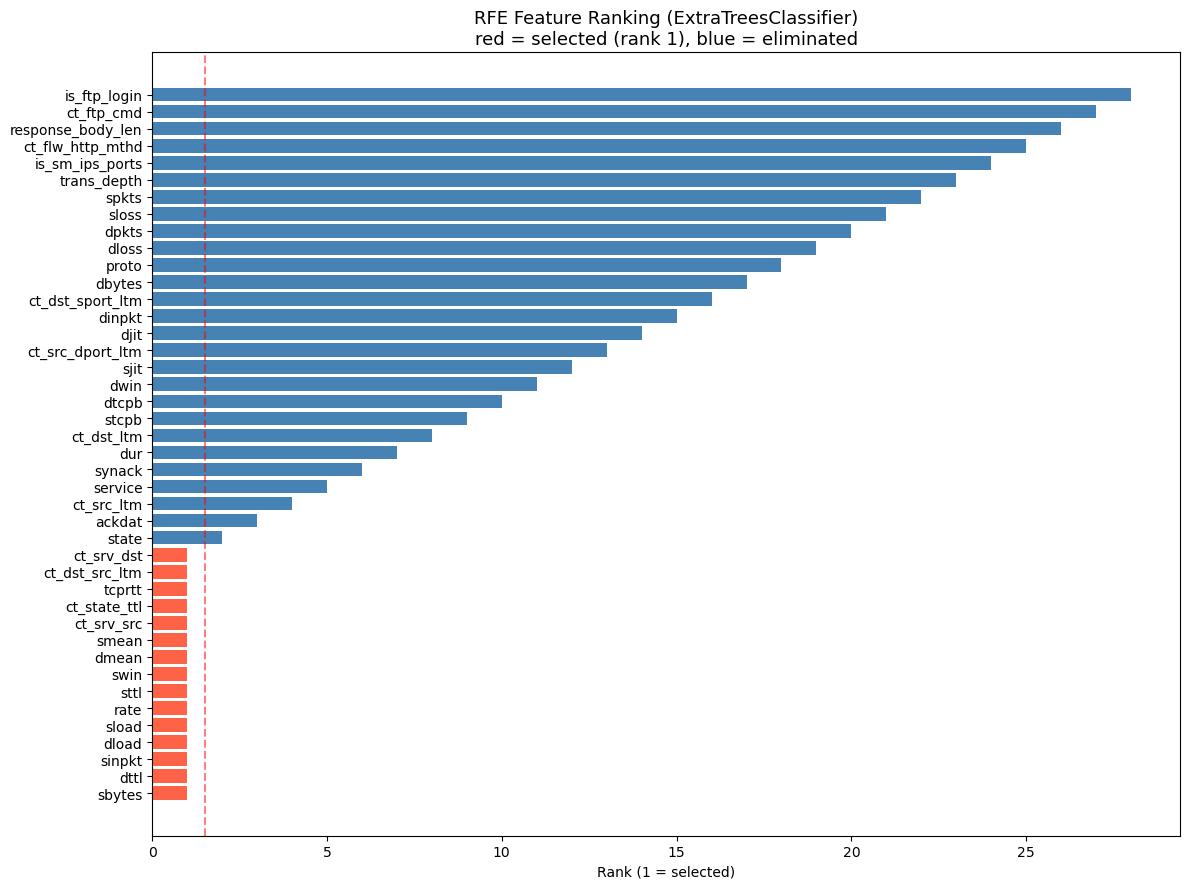

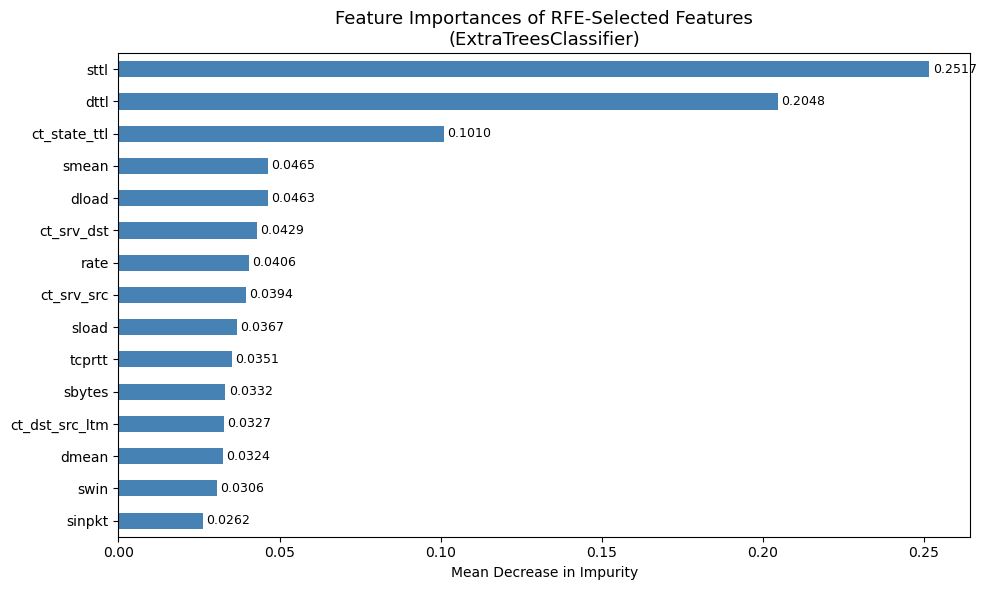

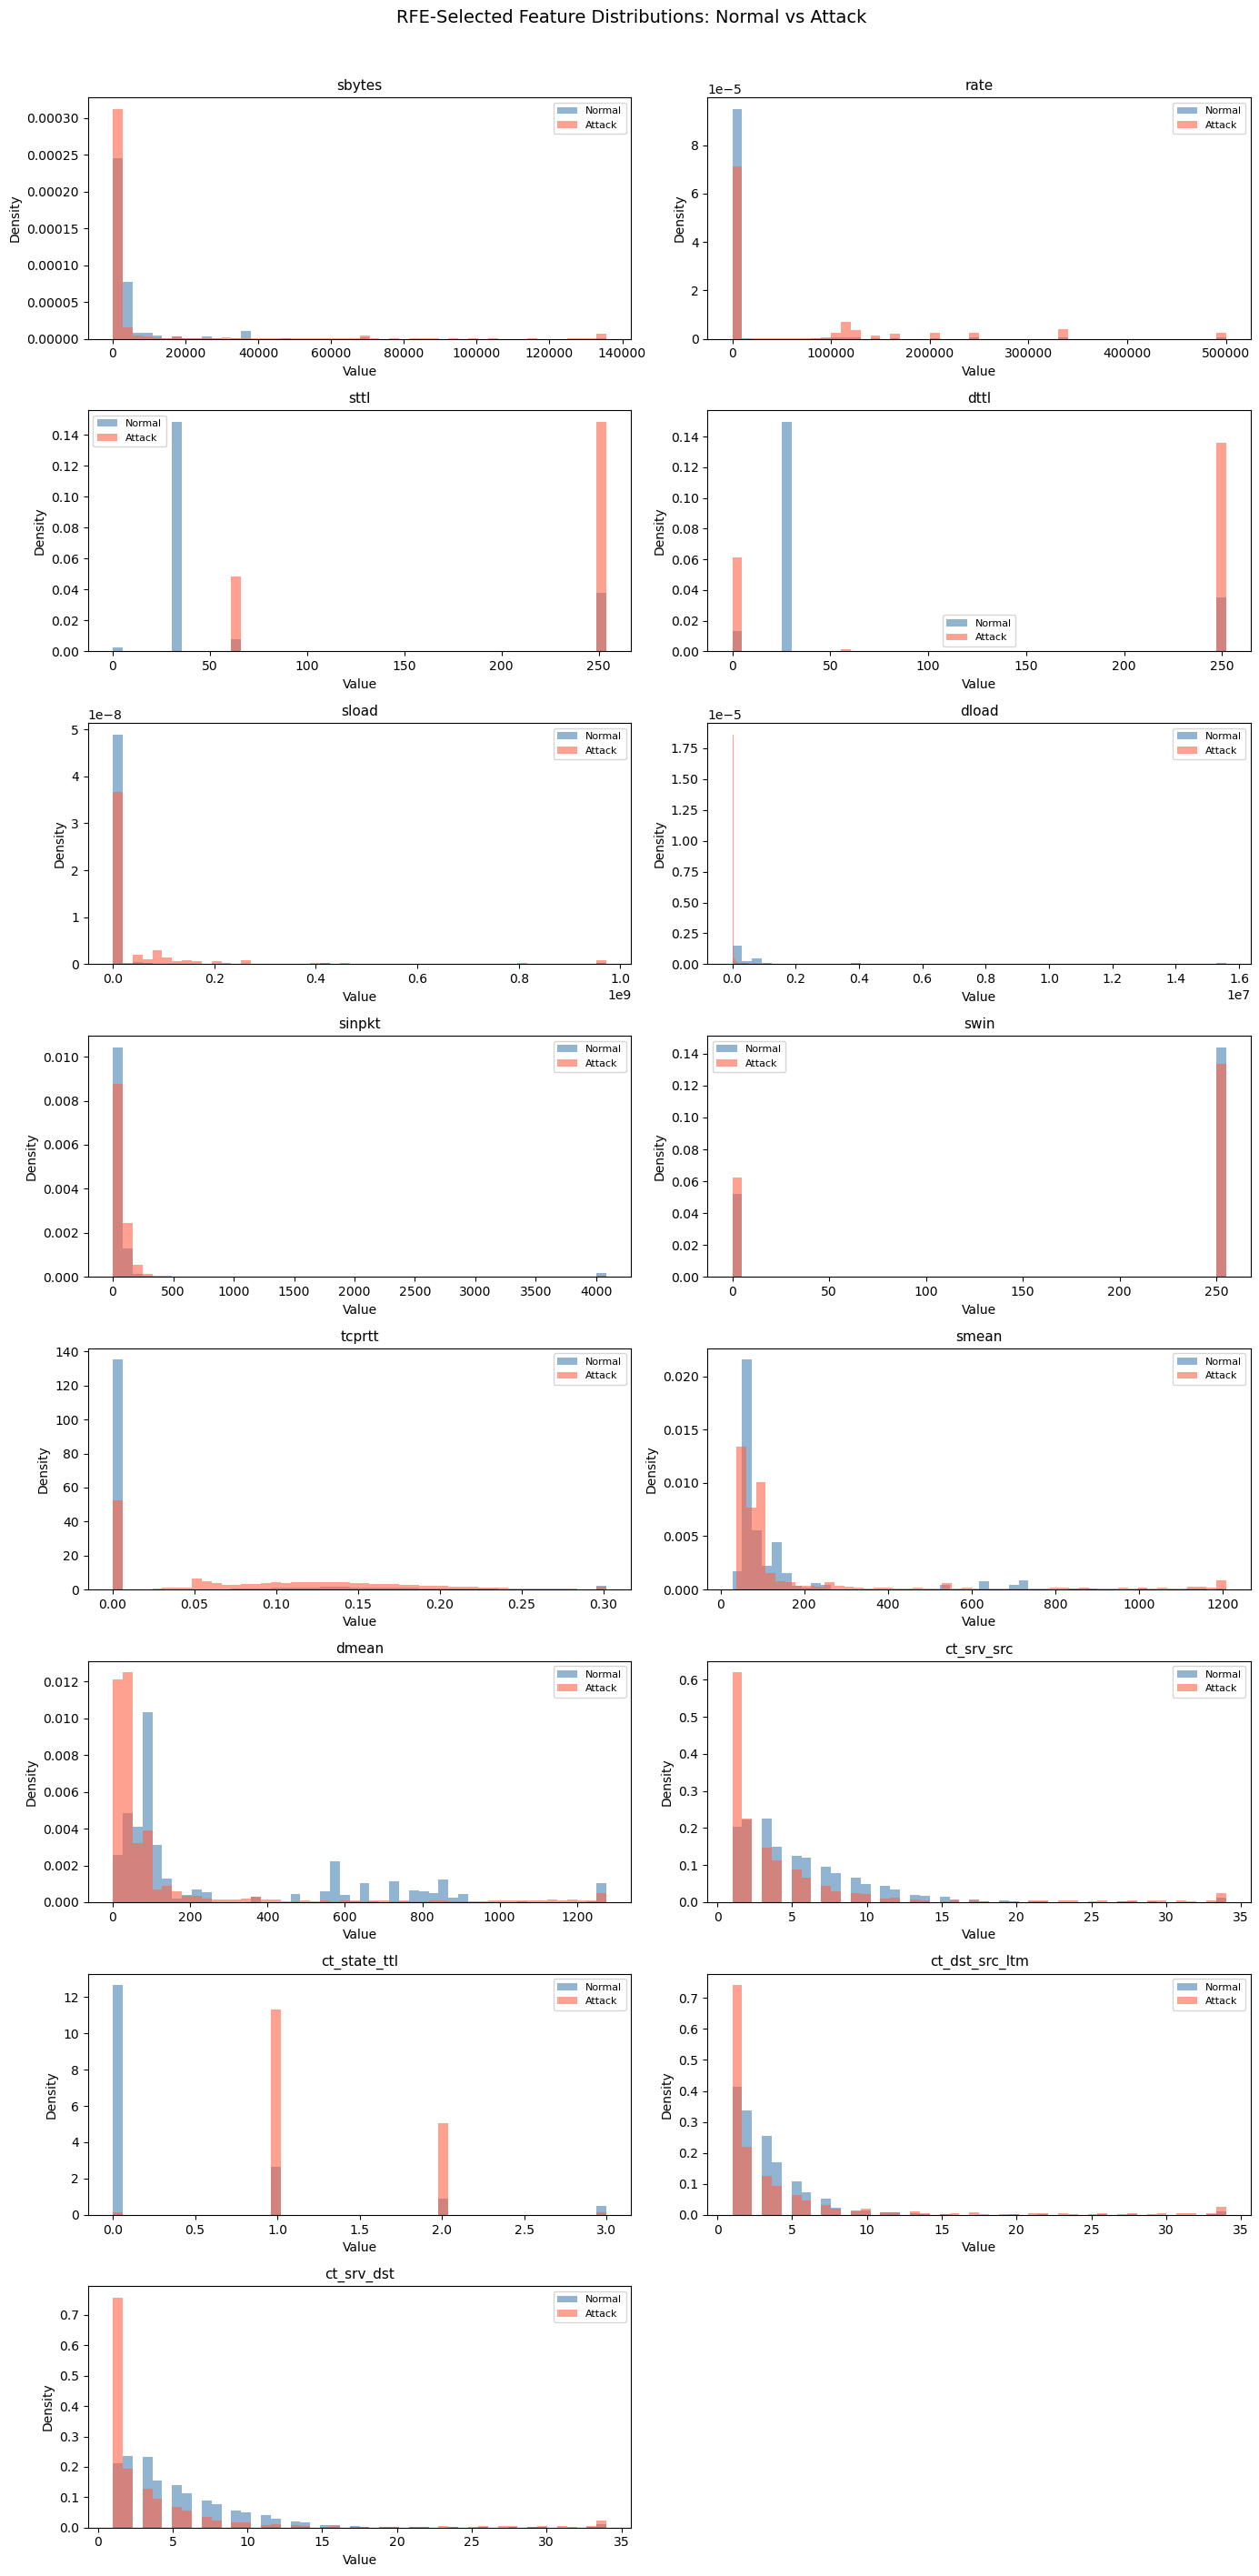

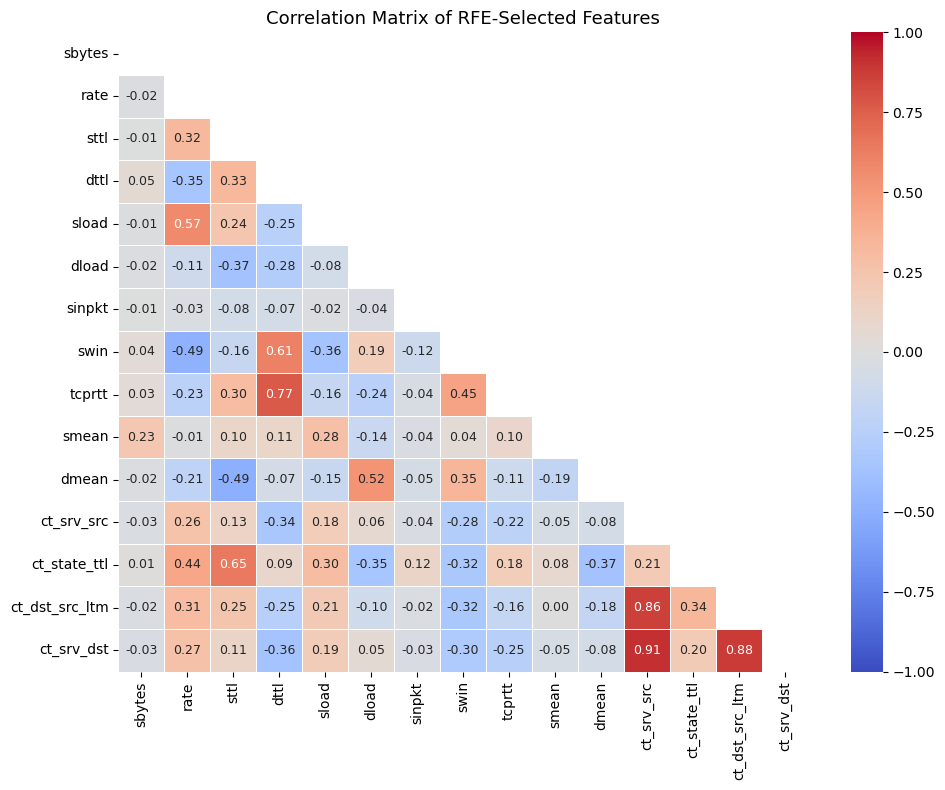

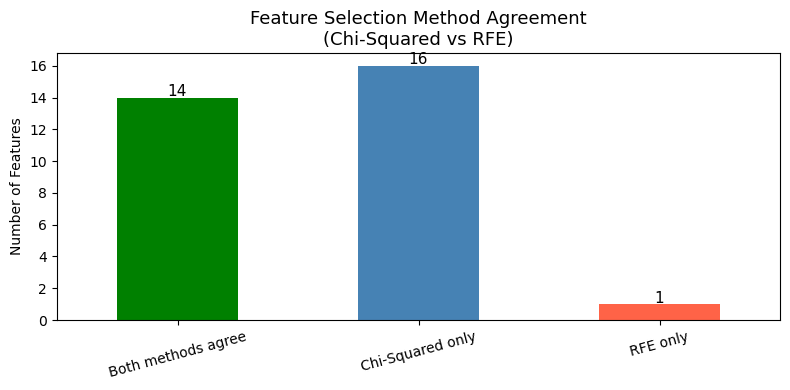

Features both methods agree on: {'sttl', 'dload', 'smean', 'sinpkt', 'sload', 'ct_state_ttl', 'ct_srv_dst', 'ct_dst_src_ltm', 'ct_srv_src', 'dttl', 'sbytes', 'swin', 'rate', 'dmean'}
Chi-Squared only: {'dinpkt', 'ct_src_dport_ltm', 'dur', 'ct_dst_ltm', 'spkts', 'state', 'djit', 'sloss', 'dbytes', 'service', 'dwin', 'sjit', 'response_body_len', 'dpkts', 'ct_dst_sport_ltm', 'dloss'}
RFE only: {'tcprtt'}
accuracy: accuracy_score: 80.89%


In [35]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── Fit RFE ───────────────────────────────────────────────────────────
etc = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfe = RFE(estimator=etc, n_features_to_select=15)
rfe.fit(X_train, y_train)

selected_features = X_train.columns[rfe.support_]
ranking = pd.Series(rfe.ranking_, index=X_train.columns)

print(f"Number of selected features: {len(selected_features)}")
print(f"Selected features: {list(selected_features)}")


# ── 1. RFE Feature Ranking ────────────────────────────────────────────
ranking_sorted = ranking.sort_values(ascending=True)
colors = ['tomato' if r == 1 else 'steelblue' for r in ranking_sorted]

plt.figure(figsize=(12, 9))
bars = plt.barh(ranking_sorted.index, ranking_sorted.values, color=colors)
plt.title('RFE Feature Ranking (ExtraTreesClassifier)\n'
          'red = selected (rank 1), blue = eliminated', fontsize=13)
plt.xlabel('Rank (1 = selected)')
plt.axvline(x=1.5, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('rfe_ranking.png', dpi=150)
plt.show()


# ── 2. ExtraTrees Feature Importance for Selected Features ────────────
# Refit ExtraTrees on selected features only to get clean importances
etc_selected = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
etc_selected.fit(X_train[selected_features], y_train)

importances = pd.Series(etc_selected.feature_importances_, 
                         index=selected_features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importances of RFE-Selected Features\n(ExtraTreesClassifier)', 
          fontsize=13)
plt.xlabel('Mean Decrease in Impurity')
for i, v in enumerate(importances):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('rfe_selected_importances.png', dpi=150)
plt.show()


# ── 3. Distributions: Normal vs Attack ───────────────────────────────
df_plot = X_train[selected_features].copy()
df_plot['label'] = y_train.values

n_cols = 2
n_rows = (len(selected_features) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(selected_features):
    cap = df_plot[feat].quantile(0.99)
    normal = df_plot[df_plot['label'] == 0][feat].clip(upper=cap)
    attack = df_plot[df_plot['label'] == 1][feat].clip(upper=cap)

    axes[i].hist(normal, bins=50, alpha=0.6, color='steelblue',
                 label='Normal', density=True)
    axes[i].hist(attack, bins=50, alpha=0.6, color='tomato',
                 label='Attack', density=True)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('RFE-Selected Feature Distributions: Normal vs Attack',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('rfe_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 4. Correlation Heatmap of Selected Features ───────────────────────
plt.figure(figsize=(10, 8))
corr = X_train[selected_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix of RFE-Selected Features', fontsize=13)
plt.tight_layout()
plt.savefig('rfe_correlation.png', dpi=150)
plt.show()


# ── 5. Chi2 vs RFE Feature Overlap (Venn-style bar) ──────────────────
# Useful if you already ran SelectKBest — shows agreement between methods
try:
    chi2_features = set(selected_features_chi2)  # from previous cell
    rfe_features  = set(selected_features)
    overlap        = chi2_features & rfe_features
    chi2_only      = chi2_features - rfe_features
    rfe_only       = rfe_features  - chi2_features

    summary = pd.Series({
        'Both methods agree': len(overlap),
        'Chi-Squared only':   len(chi2_only),
        'RFE only':           len(rfe_only)
    })

    plt.figure(figsize=(8, 4))
    summary.plot(kind='bar', color=['green', 'steelblue', 'tomato'])
    plt.title('Feature Selection Method Agreement\n(Chi-Squared vs RFE)', fontsize=13)
    plt.ylabel('Number of Features')
    plt.xticks(rotation=15)
    for i, v in enumerate(summary):
        plt.text(i, v + 0.1, str(v), ha='center', fontsize=11)
    plt.tight_layout()
    plt.savefig('method_agreement.png', dpi=150)
    plt.show()

    print(f"Features both methods agree on: {overlap}")
    print(f"Chi-Squared only: {chi2_only}")
    print(f"RFE only: {rfe_only}")
    print(f"accuracy: {f'accuracy_score: {accuracy * 100:.2f}%'}")

except NameError:
    print("Skipping overlap plot — run Chi-Squared selection first.")

In [69]:
# Recursive Feature Addition (RFA) with RandomForestClassifier
from feature_engine.selection import RecursiveFeatureAddition
from sklearn.ensemble import RandomForestClassifier

rfa = RecursiveFeatureAddition(RandomForestClassifier(random_state=42, n_jobs=4), cv=2)
rfa.fit(X_train, y_train)
selected_features_rfa = set(rfa.get_feature_names_out())

print(f"Number of selected features: {len(selected_features_rfa)}")
print(f"Selected features : {list(selected_features_rfa)}")

Number of selected features: 3
Selected features : ['smean', 'ct_state_ttl', 'sttl']


In [51]:
X_train_selected = rfa.transform(X_train)
X_test_selected = rfa.transform(X_test)

clf.fit(X_train_selected, y_train)
print(f"Accuracy : {clf.score(X_test_selected, y_test):.3f}")

Accuracy : 0.719


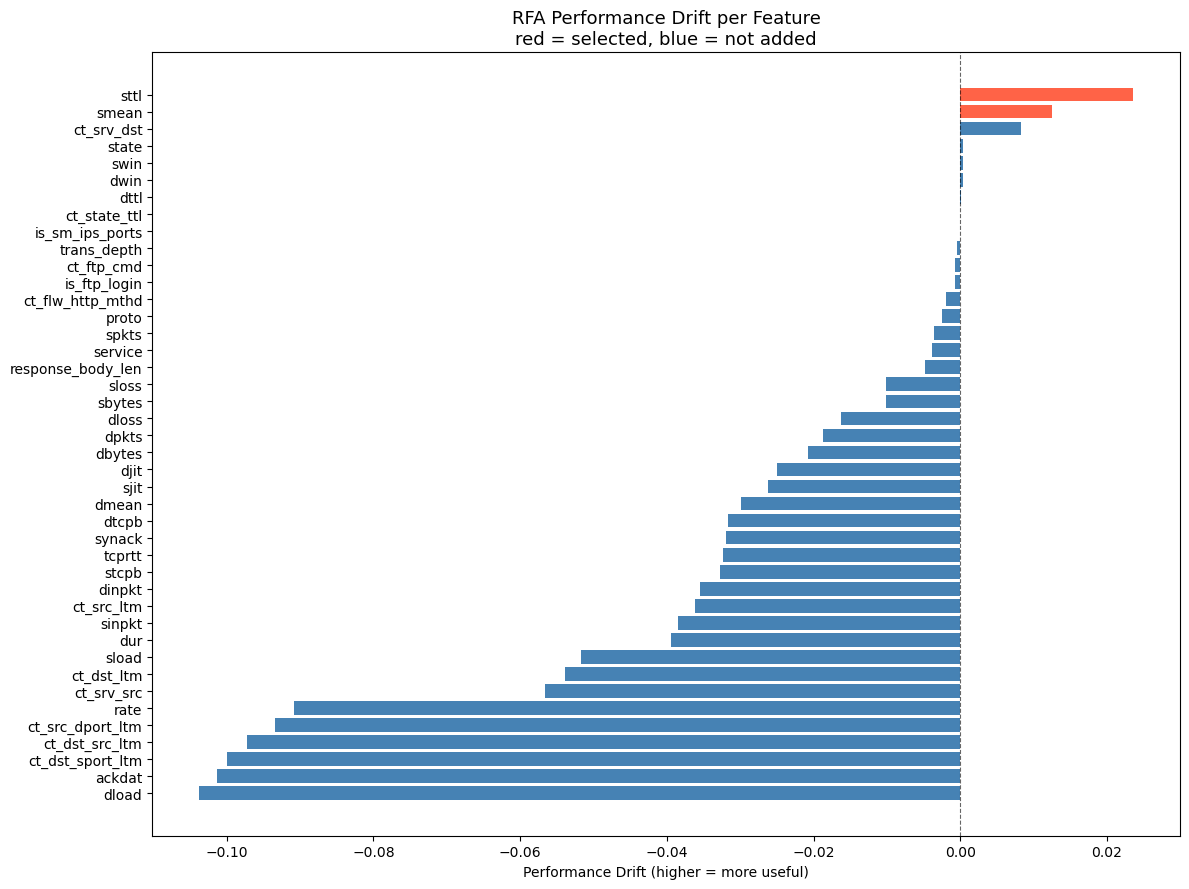

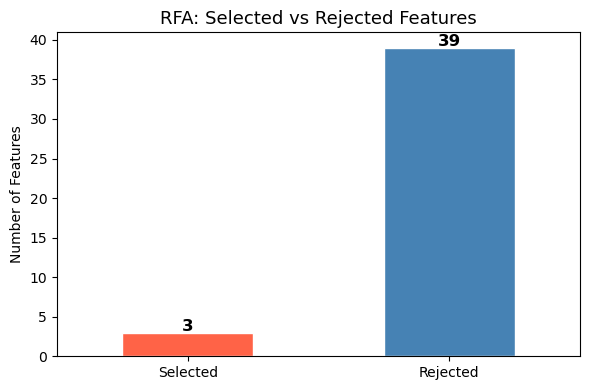

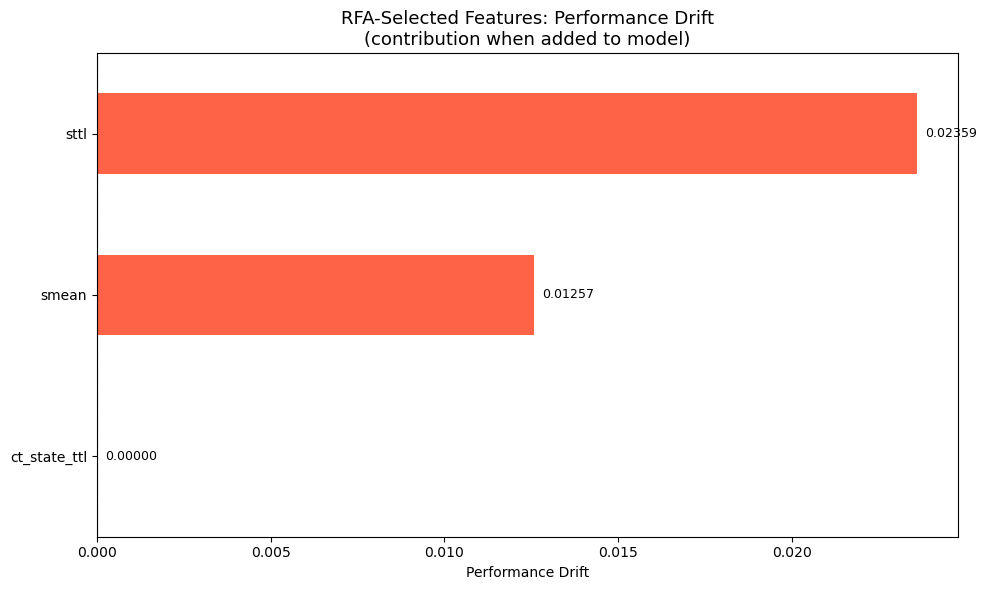

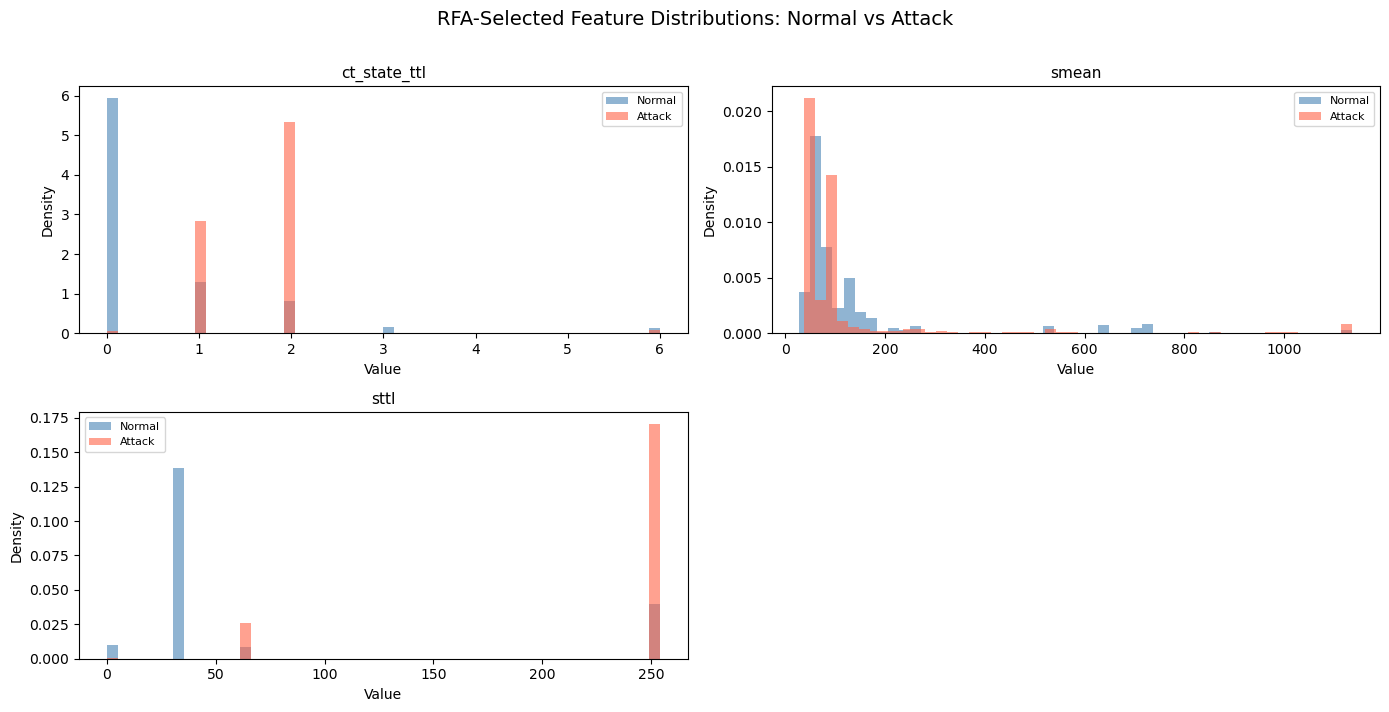

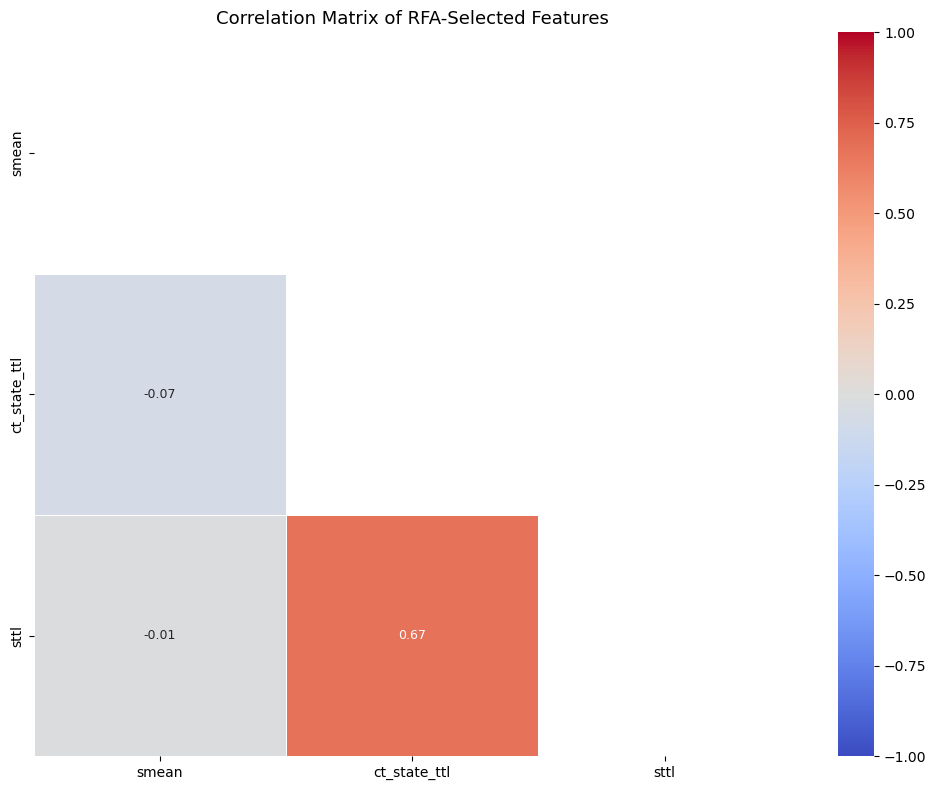

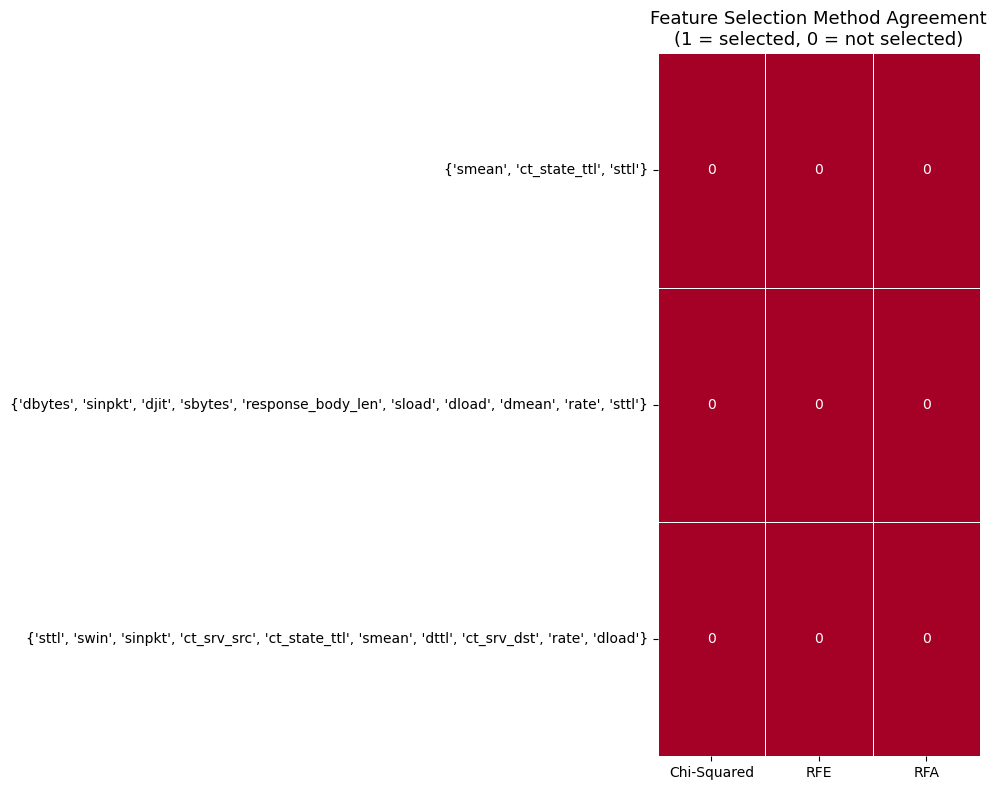


Final feature set (0): []
Selected by ALL three: []
Selected by TWO methods: []
Selected by ONE method only: []


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── Extract RFA performance data ──────────────────────────────────────
# feature_engine stores per-feature performance delta
perf_df = pd.Series(rfa.performance_drifts_).sort_values(ascending=False)
selected = set(rfa.get_feature_names_out())


# ── 1. Performance Drift per Feature ─────────────────────────────────
colors = ['tomato' if f in selected else 'steelblue' for f in perf_df.index]

plt.figure(figsize=(12, 9))
plt.barh(perf_df.index[::-1], perf_df.values[::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
plt.title('RFA Performance Drift per Feature\n'
          'red = selected, blue = not added', fontsize=13)
plt.xlabel('Performance Drift (higher = more useful)')
plt.tight_layout()
plt.savefig('rfa_performance_drift.png', dpi=150)
plt.show()


# ── 2. Selected vs Rejected count ────────────────────────────────────
counts = pd.Series({
    'Selected': len(selected),
    'Rejected': len(perf_df) - len(selected)
})

plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color=['tomato', 'steelblue'], edgecolor='white')
plt.title('RFA: Selected vs Rejected Features', fontsize=13)
plt.ylabel('Number of Features')
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    plt.text(i, v + 0.2, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('rfa_selected_vs_rejected.png', dpi=150)
plt.show()


# ── 3. Top selected features — drift bar chart ────────────────────────
selected_drift = perf_df[perf_df.index.isin(selected)].sort_values(ascending=True)

plt.figure(figsize=(10, 6))
selected_drift.plot(kind='barh', color='tomato')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
plt.title('RFA-Selected Features: Performance Drift\n'
          '(contribution when added to model)', fontsize=13)
plt.xlabel('Performance Drift')
for i, v in enumerate(selected_drift):
    offset = selected_drift.abs().max() * 0.01
    plt.text(v + offset if v >= 0 else v - offset, i,
             f'{v:.5f}', va='center', fontsize=9,
             ha='left' if v >= 0 else 'right')
plt.tight_layout()
plt.savefig('rfa_selected_drift.png', dpi=150)
plt.show()


# ── 4. Feature Distributions: Normal vs Attack ────────────────────────
df_plot = X_train[list(selected)].copy()
df_plot['label'] = y_train.values

n_cols = 2
n_rows = (len(selected) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(sorted(selected)):
    cap = df_plot[feat].quantile(0.99)
    normal = df_plot[df_plot['label'] == 0][feat].clip(upper=cap)
    attack = df_plot[df_plot['label'] == 1][feat].clip(upper=cap)

    axes[i].hist(normal, bins=50, alpha=0.6, color='steelblue',
                 label='Normal', density=True)
    axes[i].hist(attack, bins=50, alpha=0.6, color='tomato',
                 label='Attack', density=True)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('RFA-Selected Feature Distributions: Normal vs Attack',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('rfa_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 5. Correlation Heatmap of Selected Features ───────────────────────
plt.figure(figsize=(10, 8))
corr = X_train[list(selected)].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix of RFA-Selected Features', fontsize=13)
plt.tight_layout()
plt.savefig('rfa_correlation.png', dpi=150)
plt.show()


# ── 6. Three-method agreement summary ────────────────────────────────
all_features = sorted((selected_features_chi2,selected_features_rfe,selected_features_rfa))

agreement = pd.DataFrame({
    'Chi-Squared': [f in selected_features_chi2 for f in all_features],
    'RFE':         [f in selected_features_rfe  for f in all_features],
    'RFA':         [f in selected_features_rfa  for f in all_features],
}, index=all_features)

agreement['votes'] = agreement.sum(axis=1)
agreement = agreement.sort_values('votes', ascending=False)

# ── Plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
sns.heatmap(agreement[['Chi-Squared', 'RFE', 'RFA']].astype(int),
            annot=True, fmt='d', cmap='RdYlGn',
            linewidths=0.5, cbar=False,
            yticklabels=agreement.index)
plt.title('Feature Selection Method Agreement\n'
          '(1 = selected, 0 = not selected)', fontsize=13)
plt.tight_layout()
plt.savefig('three_method_agreement.png', dpi=150)
plt.show()

# ── Final feature set ─────────────────────────────────────────────────
final_features = agreement[agreement['votes'] >= 2].index.tolist()

print(f"\nFinal feature set ({len(final_features)}): {final_features}")
for votes in [3, 2, 1]:
    features = agreement[agreement['votes'] == votes].index.tolist()
    label = {3: 'ALL three', 2: 'TWO methods', 1: 'ONE method only'}[votes]
    print(f"Selected by {label}: {features}")

Chi-Squared: {'sttl', 'dbytes', 'sinpkt', 'djit', 'sbytes', 'response_body_len', 'sload', 'dmean', 'rate', 'dload'}
RFE        : {'swin', 'sinpkt', 'ct_srv_src', 'ct_state_ttl', 'dload', 'smean', 'dttl', 'ct_srv_dst', 'rate', 'sttl'}
RFA        : {'smean', 'ct_state_ttl', 'sttl'}


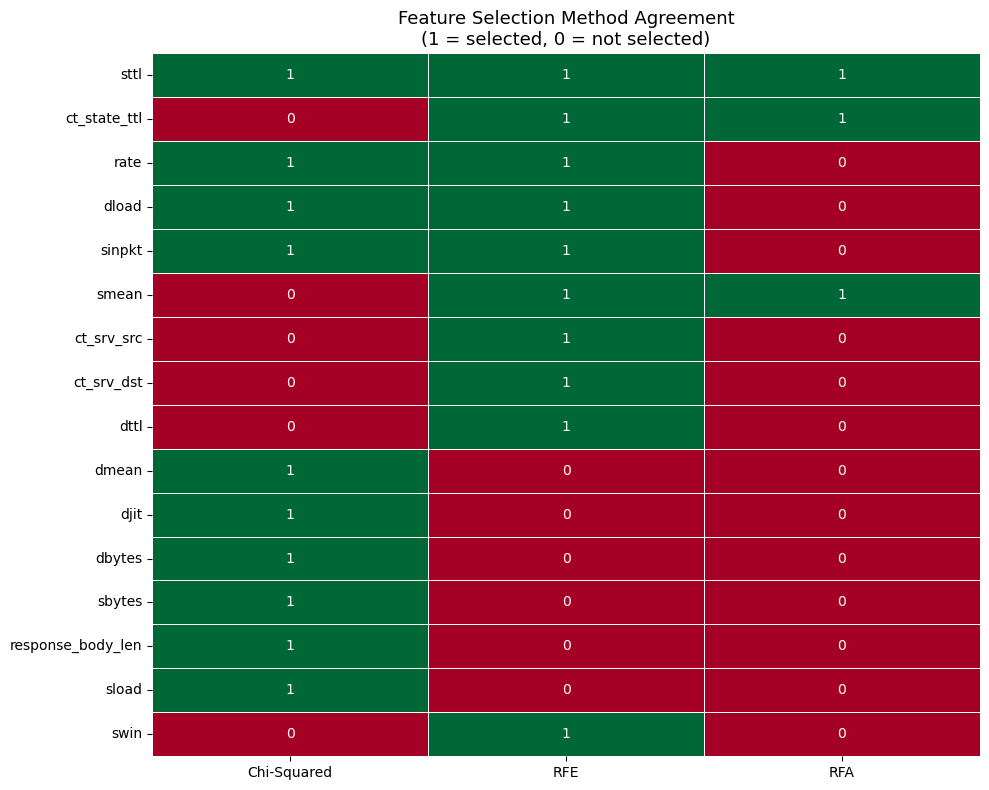


Final feature set (6): ['sttl', 'ct_state_ttl', 'rate', 'dload', 'sinpkt', 'smean']
Selected by ALL three: ['sttl']
Selected by TWO methods: ['ct_state_ttl', 'rate', 'dload', 'sinpkt', 'smean']
Selected by ONE method only: ['ct_srv_src', 'ct_srv_dst', 'dttl', 'dmean', 'djit', 'dbytes', 'sbytes', 'response_body_len', 'sload', 'swin']


In [72]:
# Force each to be a clean flat set of strings
selected_features_chi2 = set(str(f) for f in selected_features_chi2)
selected_features_rfe  = set(str(f) for f in selected_features_rfe)
selected_features_rfa  = set(str(f) for f in selected_features_rfa)

# Verify — each should print individual feature names
print("Chi-Squared:", selected_features_chi2)
print("RFE        :", selected_features_rfe)
print("RFA        :", selected_features_rfa)

# Now build agreement
all_features = sorted(selected_features_chi2 | selected_features_rfe | selected_features_rfa)

agreement = pd.DataFrame({
    'Chi-Squared': [f in selected_features_chi2 for f in all_features],
    'RFE':         [f in selected_features_rfe  for f in all_features],
    'RFA':         [f in selected_features_rfa  for f in all_features],
}, index=all_features)

agreement['votes'] = agreement.sum(axis=1)
agreement = agreement.sort_values('votes', ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(agreement[['Chi-Squared', 'RFE', 'RFA']].astype(int),
            annot=True, fmt='d', cmap='RdYlGn',
            linewidths=0.5, cbar=False)
plt.title('Feature Selection Method Agreement\n'
          '(1 = selected, 0 = not selected)', fontsize=13)
plt.tight_layout()
plt.savefig('three_method_agreement.png', dpi=150)
plt.show()

final_features = agreement[agreement['votes'] >= 2].index.tolist()
print(f"\nFinal feature set ({len(final_features)}): {final_features}")
for votes in [3, 2, 1]:
    features = agreement[agreement['votes'] == votes].index.tolist()
    label = {3: 'ALL three', 2: 'TWO methods', 1: 'ONE method only'}[votes]
    print(f"Selected by {label}: {features}")

Training Random Forest...
Training Isolation Forest...
  Contamination set to: 0.5184 (51.8% attack)

── Classification Metrics (6 features) ──────────────────────
                  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest       0.8732     0.8223  0.9820    0.8951   0.9743
Isolation Forest    0.5580     0.7775  0.2764    0.4078   0.6466

  Random Forest
              precision    recall  f1-score   support

      Normal       0.97      0.74      0.84     37000
      Attack       0.82      0.98      0.90     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.87     82332
weighted avg       0.89      0.87      0.87     82332


  Isolation Forest
              precision    recall  f1-score   support

      Normal       0.50      0.90      0.65     37000
      Attack       0.78      0.28      0.41     45332

    accuracy                           0.56     82332
   macro avg       0.64      0.59      0.53     82332
weigh

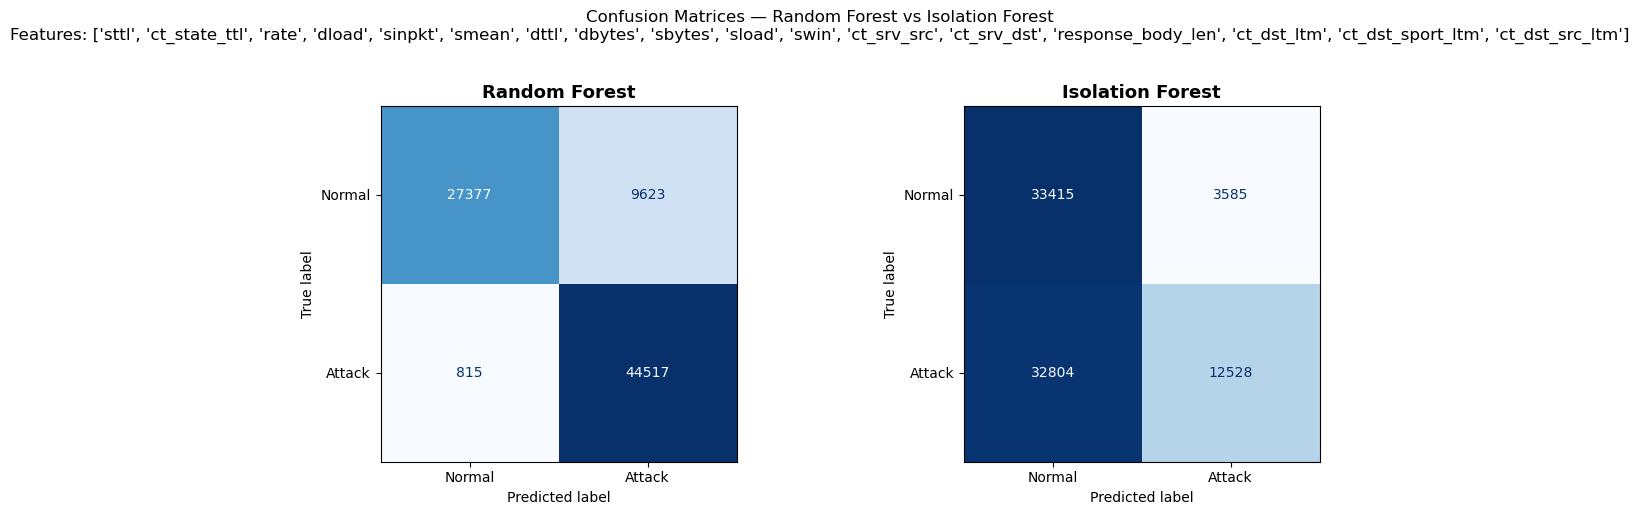

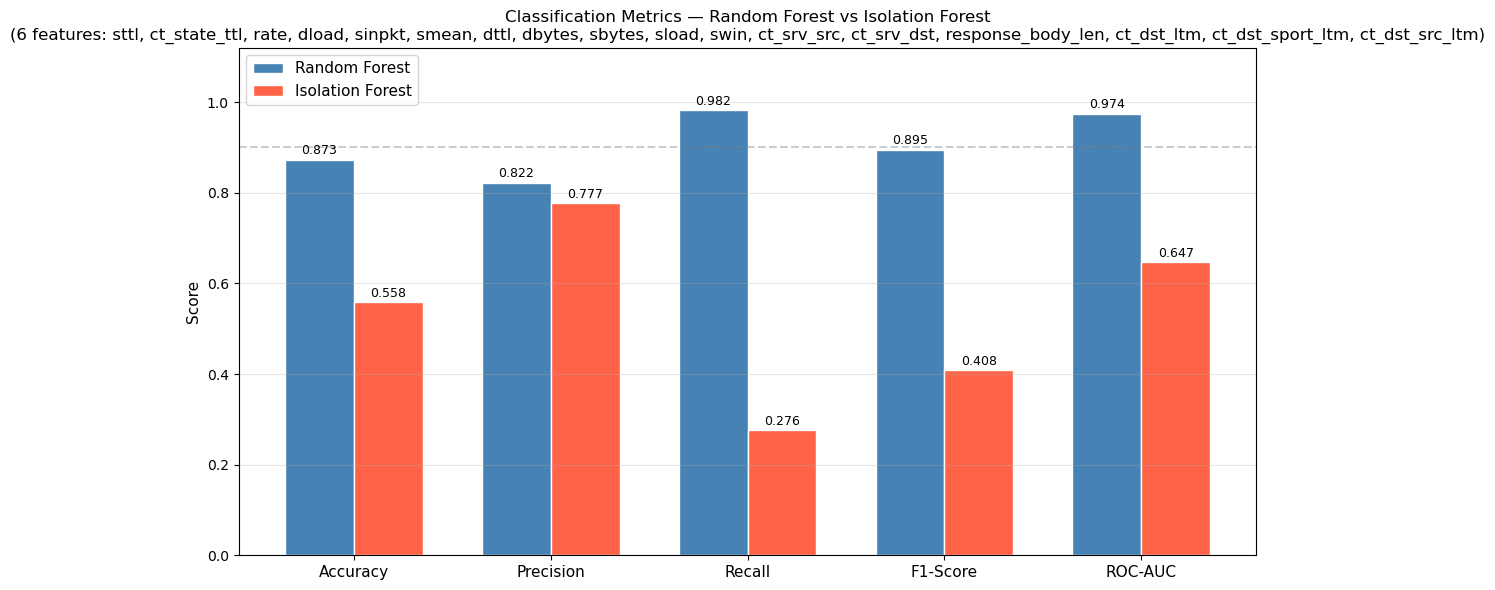

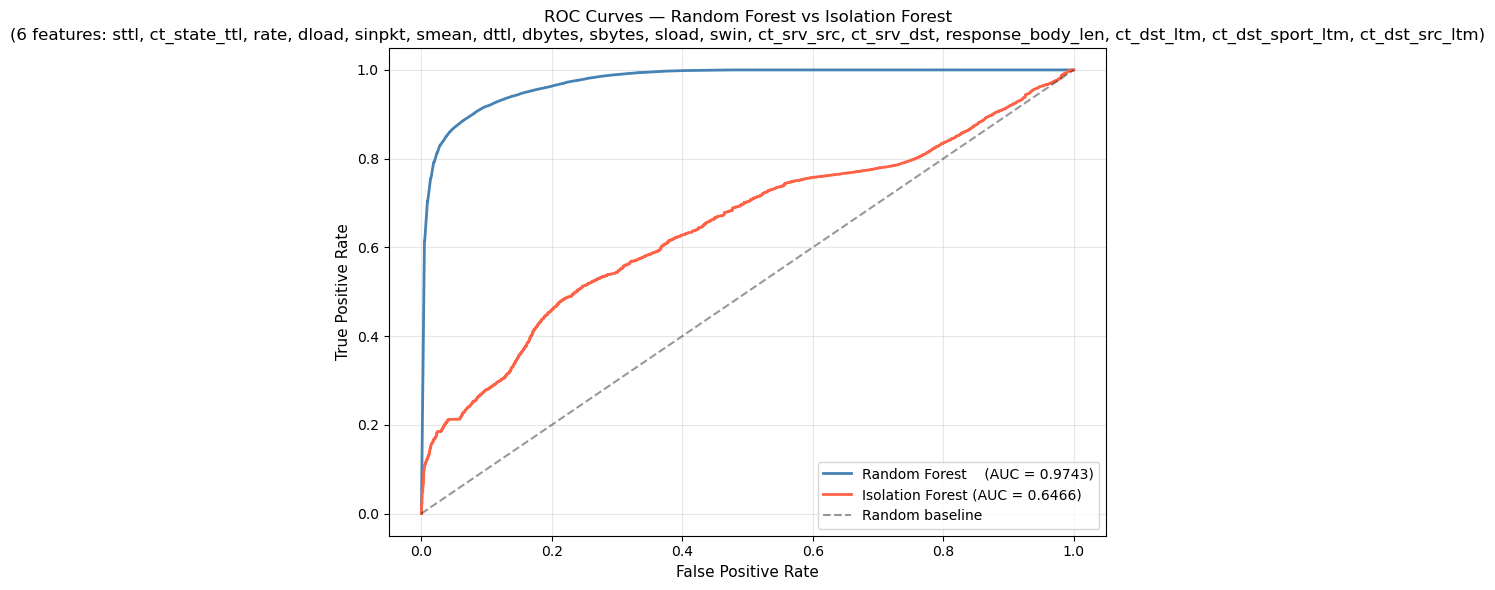

In [ ]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

X_train_final = X_train[]
X_test_final  = X_test[]

# ── 1. Random Forest ──────────────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_final, y_train)
y_pred_rf  = rf.predict(X_test_final)
y_prob_rf  = rf.predict_proba(X_test_final)[:, 1]

# ── 2. Isolation Forest ───────────────────────────────────────────────
print("Training Isolation Forest...")
# Estimate contamination from training labels
contamination = float(y_train.mean())
print(f"  Contamination set to: {contamination:.4f} ({contamination*100:.1f}% attack)")

isof = IsolationForest(n_estimators=100, contamination='auto',
                       random_state=42, n_jobs=-1)
isof.fit(X_train_final)                          # unsupervised — no y_train
y_pred_isof_raw = isof.predict(X_test_final)
y_pred_isof     = np.where(y_pred_isof_raw == -1, 1, 0)  # -1=attack→1, 1=normal→0
y_score_isof    = -isof.decision_function(X_test_final)   # higher = more anomalous

# ── 3. Metrics summary ────────────────────────────────────────────────
roc_rf   = roc_auc_score(y_test, y_prob_rf)
roc_isof = roc_auc_score(y_test, y_score_isof)

summary = pd.DataFrame({
    'Accuracy' : [accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_isof)],
    'Precision': [precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_isof)],
    'Recall'   : [recall_score(y_test, y_pred_rf),
                  recall_score(y_test, y_pred_isof)],
    'F1-Score' : [f1_score(y_test, y_pred_rf),
                  f1_score(y_test, y_pred_isof)],
    'ROC-AUC'  : [roc_rf, roc_isof]
}, index=['Random Forest', 'Isolation Forest']).round(4)

print("\n── Classification Metrics (6 features) ──────────────────────")
print(summary.to_string())

# ── 4. Full classification reports ───────────────────────────────────
for name, y_pred in [('Random Forest',    y_pred_rf),
                     ('Isolation Forest', y_pred_isof)]:
    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(classification_report(y_test, y_pred,
                                target_names=['Normal', 'Attack']))

# ── 5. Side-by-side confusion matrices ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [('Random Forest',    y_pred_rf),
                                      ('Isolation Forest', y_pred_isof)]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Normal', 'Attack'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Random Forest vs Isolation Forest\n'
             f'Features: {final_features}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_6features.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. Metrics bar chart ──────────────────────────────────────────────
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
rf_scores   = summary.loc['Random Forest',    metrics].values
isof_scores = summary.loc['Isolation Forest', metrics].values

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, rf_scores,   width, label='Random Forest',
               color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, isof_scores, width, label='Isolation Forest',
               color='tomato',    edgecolor='white')

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Classification Metrics — Random Forest vs Isolation Forest\n'
             f'(6 features: {", ".join(final_features)})', fontsize=12)
ax.legend(fontsize=11)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4, label='0.9 threshold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_comparison_6features.png', dpi=150)
plt.show()

# ── 7. ROC curves ────────────────────────────────────────────────────
from sklearn.metrics import roc_curve

fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_prob_rf)
fpr_isof, tpr_isof, _ = roc_curve(y_test, y_score_isof)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,   tpr_rf,   color='steelblue', lw=2,
         label=f'Random Forest    (AUC = {roc_rf:.4f})')
plt.plot(fpr_isof, tpr_isof, color='tomato',    lw=2,
         label=f'Isolation Forest (AUC = {roc_isof:.4f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random baseline')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate',  fontsize=11)
plt.title('ROC Curves — Random Forest vs Isolation Forest\n'
          f'(6 features: {", ".join(final_features)})', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_6features.png', dpi=150)
plt.show()

Before SMOTE:
  Normal (0): 56000
  Attack (1): 119341
  Ratio     : 0.47:1

After SMOTE:
  Normal (0): 119341
  Attack (1): 119341
  Ratio     : 1.00:1
  New training size: (238682, 13)


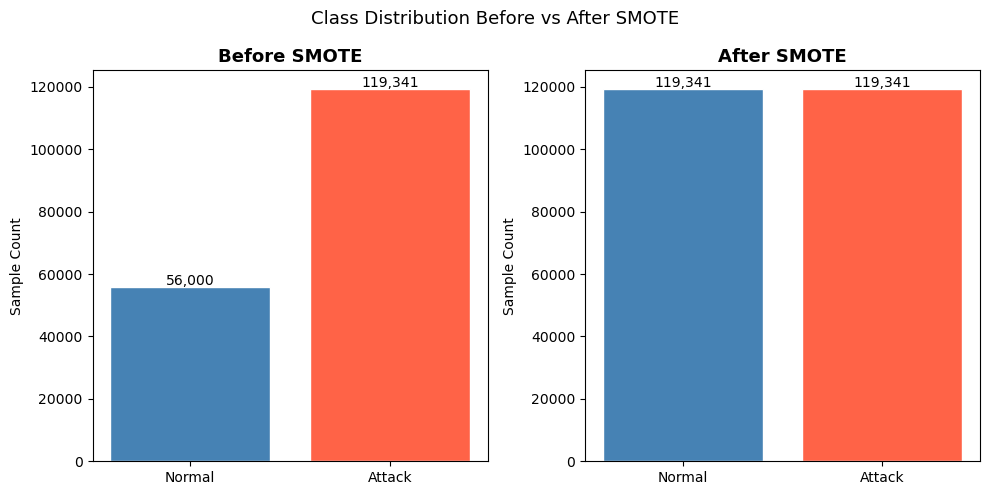

In [20]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# ── Check class balance before ────────────────────────────────────────
print("Before SMOTE:")
print(f"  Normal (0): {Counter(y_train)[0]}")
print(f"  Attack (1): {Counter(y_train)[1]}")
print(f"  Ratio     : {Counter(y_train)[0] / Counter(y_train)[1]:.2f}:1")

# ── Apply SMOTE on training set only ─────────────────────────────────
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

# ── Check class balance after ─────────────────────────────────────────
print("\nAfter SMOTE:")
print(f"  Normal (0): {Counter(y_train_smote)[0]}")
print(f"  Attack (1): {Counter(y_train_smote)[1]}")
print(f"  Ratio     : {Counter(y_train_smote)[0] / Counter(y_train_smote)[1]:.2f}:1")
print(f"  New training size: {X_train_smote.shape}")

# ── Visualise before vs after ─────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (counts, title) in zip(axes, [
    (Counter(y_train),       'Before SMOTE'),
    (Counter(y_train_smote), 'After SMOTE')
]):
    bars = ax.bar(['Normal', 'Attack'],
                  [counts[0], counts[1]],
                  color=['steelblue', 'tomato'],
                  edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Sample Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 500,
                f'{int(bar.get_height()):,}',
                ha='center', fontsize=10)

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=13)
plt.tight_layout()
plt.savefig('smote_balance.png', dpi=150)
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report
import numpy as np

# ── Random Forest on SMOTE data ───────────────────────────────────────
print("Training Random Forest on SMOTE data...")
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test_final)

# ── Isolation Forest on SMOTE data ───────────────────────────────────
print("Training Isolation Forest on SMOTE data...")
isof_smote = IsolationForest(n_estimators=100, contamination=0.5,
                              random_state=42, n_jobs=-1)
isof_smote.fit(X_train_smote)
y_pred_isof_smote = np.where(
    isof_smote.predict(X_test_final) == -1, 1, 0
)

# ── Compare before vs after SMOTE ────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

comparison = pd.DataFrame({
    'RF (before SMOTE)':   [accuracy_score(y_test, y_pred_rf),
                            precision_score(y_test, y_pred_rf),
                            recall_score(y_test, y_pred_rf),
                            f1_score(y_test, y_pred_rf)],
    'RF (after SMOTE)':    [accuracy_score(y_test, y_pred_rf_smote),
                            precision_score(y_test, y_pred_rf_smote),
                            recall_score(y_test, y_pred_rf_smote),
                            f1_score(y_test, y_pred_rf_smote)],
    'IF (before SMOTE)':   [accuracy_score(y_test, y_pred_isof),
                            precision_score(y_test, y_pred_isof),
                            recall_score(y_test, y_pred_isof),
                            f1_score(y_test, y_pred_isof)],
    'IF (after SMOTE)':    [accuracy_score(y_test, y_pred_isof_smote),
                            precision_score(y_test, y_pred_isof_smote),
                            recall_score(y_test, y_pred_isof_smote),
                            f1_score(y_test, y_pred_isof_smote)],
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).round(4)

print("\nBefore vs After SMOTE Comparison:")
print(comparison.to_string())

Training Random Forest on SMOTE data...
Training Isolation Forest on SMOTE data...

Before vs After SMOTE Comparison:
           RF (before SMOTE)  RF (after SMOTE)  IF (before SMOTE)  IF (after SMOTE)
Accuracy              0.8643            0.8847             0.4164            0.4282
Precision             0.8219            0.8559             0.3699            0.4778
Recall                0.9619            0.9507             0.0853            0.4139
F1-Score              0.8864            0.9008             0.1386            0.4436
